In [41]:
import os

import matplotlib.pyplot as plt
import torch
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision.transforms.v2 import functional as F
from torchvision.transforms import v2 as T
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

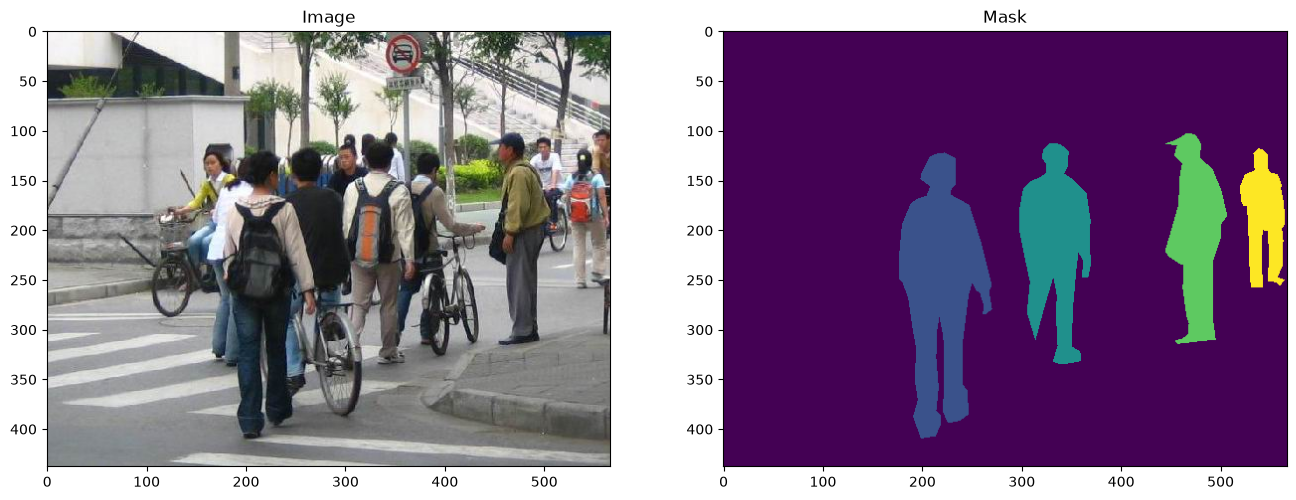

In [42]:
image = read_image("datasets/PenFeddan/PNGImages/FudanPed00046.png")
mask = read_image("datasets/PenFeddan/PedMasks/FudanPed00046_mask.png")

# A BIT of RECAP - row, column, plot
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))

## Custom dataset care folosesc imaginiile, bounxding box-urile si mastile


In [43]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        obj_ids = torch.unique(mask)
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        boxes = masks_to_boxes(masks)
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(
            boxes, format="XYXY", canvas_size=F.get_size(img)
        )
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)

In [44]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weithgs="DEFAULT")
num_classes = 2

In [45]:
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predcitor = FastRCNNPredictor(in_features, num_classes)

In [46]:
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
backbone.out_channels = 1280

anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),), aspect_ratios=((0.5, 1.0, 2.0),)
)

In [47]:
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=["0"], output_size=7, sampling_ratio=2
)

model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler,
)

In [48]:
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model


In [49]:
import urllib.request
from pathlib import Path

# Helper-ele oficiale din torchvision/references/detection (nu vin cu pachetul instalat).
# urllib in loc de wget/curl: merge identic pe macOS, Linux si Windows, iar erorile
# apar in celula, nu in terminalul din care ai pornit Jupyter.
BASE = "https://raw.githubusercontent.com/pytorch/vision/main/references/detection"
FILES = ["engine.py", "utils.py", "coco_utils.py", "coco_eval.py", "transforms.py"]

for name in FILES:
    dest = Path(name)
    if dest.exists():
        print(f"{name} — deja descarcat, sar peste")
        continue
    urllib.request.urlretrieve(f"{BASE}/{name}", dest)
    print(f"{name} — descarcat ({dest.stat().st_size} bytes)")

# TODO(human): verifica aici ca `import utils` chiar ia fisierul descarcat acum,
# nu alt pachet `utils` din environment (exact bug-ul in care ai dat mai jos).
# Doua lucruri de aflat: din ce fisier vine modulul, si daca are `collate_fn`.
# Atentie: daca ai rulat deja `import utils` in sesiunea asta, modulul gresit e
# in cache-ul din sys.modules — un simplu import nu-l inlocuieste.


engine.py — deja descarcat, sar peste
utils.py — deja descarcat, sar peste
coco_utils.py — deja descarcat, sar peste
coco_eval.py — deja descarcat, sar peste
transforms.py — deja descarcat, sar peste


In [50]:
def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [51]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = PennFudanDataset("datasets/PenFeddan", get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn
)

images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)
print(output)

model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)
print(predictions[0])

{'loss_classifier': tensor(0.1455, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0224, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0361, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0012, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


In [ ]:
from engine import train_one_epoch, evaluate

# train on the accelerator or on the CPU, if an accelerator is not available
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset = PennFudanDataset("datasets/PenFeddan", get_transform(train=True))
dataset_test = PennFudanDataset("datasets/PenFeddan", get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, collate_fn=utils.collate_fn
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# let's train it just for 2 epochs
num_epochs = 2

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /Users/cosminrosculet/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:03<00:00, 57.5MB/s] 
/Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 2:05:35  lr: 0.000090  loss: 3.5314 (3.5314)  loss_classifier: 0.8355 (0.8355)  loss_box_reg: 0.2536 (0.2536)  loss_mask: 2.4257 (2.4257)  loss_objectness: 0.0114 (0.0114)  loss_rpn_box_reg: 0.0052 (0.0052)  time: 125.5861  data: 0.0219


In [ ]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image("datasets/PenFeddan/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model(
        [
            x,
        ]
    )
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [
    f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])
]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
